In [ ]:
!pip install kaggle -q
!pip install -q opencv-python-headless Pillow torch torchvision torchaudio tqdm scikit-learn matplotlib
!pip install -q wandb
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 15.5 MB/s eta 0:00:00


In [ ]:
# ==========================================
# 1. CONFIGURACIÓN Y DESCARGAS
# ==========================================
import os
import sys

# Instalar librería de Kaggle
!pip install -q kagglehub
import kagglehub

print("⬇️ [1/3] Descargando Dataset de Imágenes...")
path_dataset_root = kagglehub.dataset_download("javiersarango/coffee-roast-agtron-scale-dataset")

# Ajustar ruta si hay subcarpetas
if os.path.exists(os.path.join(path_dataset_root, "DatasetCoffee")):
    DATASET_DIR = os.path.join(path_dataset_root, "DatasetCoffee")
else:
    DATASET_DIR = path_dataset_root

print(f"📂 Imágenes en: {DATASET_DIR}")

print("\n⬇️ [2/3] Clonando Modelos desde GitHub...")
REPO_URL = "https://github.com/JavierSarango/roast-coffee-agtron.git"
if not os.path.exists("roast-coffee-agtron"):
    !git clone {REPO_URL}



⬇️ [1/3] Descargando Dataset de Imágenes...


100%|██████████| 14.3G/14.3G [06:34<00:00, 38.8MB/s]


Extracting files...
📂 Imágenes en: /root/.cache/kagglehub/datasets/javiersarango/coffee-roast-agtron-scale-dataset/versions/1/DatasetCoffee

⬇️ [2/3] Clonando Modelos desde GitHub...
Cloning into 'roast-coffee-agtron'...
remote: Enumerating objects: 10085, done.
remote: Total 10085 (delta 0), reused 0 (delta 0), pack-reused 10085 (from 1)
Receiving objects: 100% (10085/10085), 647.89 MiB | 32.81 MiB/s, done.
Resolving deltas: 100% (638/638), done.
Updating files: 100% (10067/10067), done.


In [ ]:
MODELS_DIR = "/content/roast-coffee-agtron/exp4"

# Nombres de archivos esperados
FILE_MODEL_A = 'cnn_segmented_cnn_(optimizado)_best.pth'
FILE_MODEL_B = 'cnn_original_cnn_(optimizado)_best.pth'

In [ ]:
# Configurar permisos
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("javiersarango/coffee-roast-agtron-scale-dataset")

# print("Path to dataset files:", path)

In [ ]:
# ==========================================
# 2. LIBRERÍAS Y PARÁMETROS
# ==========================================
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from torchvision import transforms

SEED = 42
IMG_SIZE = (128, 128)
CHANNELS = 3
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n⚙️ Dispositivo de procesamiento: {DEVICE}")



⚙️ Dispositivo de procesamiento: cuda


In [ ]:
# ==========================================
# 3. DEFINICIÓN DE ARQUITECTURAS
# ==========================================

# --- U-Net ---
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.e1 = conv_block(in_channels, 16); self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.e2 = conv_block(16, 32)
        self.bridge = conv_block(32, 64)
        self.up_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.d1 = conv_block(32 + 32, 32)
        self.up_conv2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.d2 = conv_block(16 + 16, 16)
        self.out = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        c1 = self.e1(x); p1 = self.maxpool(c1)
        c2 = self.e2(p1); p2 = self.maxpool(c2)
        c3 = self.bridge(p2)
        u4 = self.up_conv1(c3); u4 = torch.cat([u4, c2], dim=1); c4 = self.d1(u4)
        u5 = self.up_conv2(c4); u5 = torch.cat([u5, c1], dim=1); c5 = self.d2(u5)
        return self.out(c5)

# --- CNN ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(CHANNELS, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [ ]:
# ==========================================
# 4. RECUPERAR TEST SET (SPLIT)
# ==========================================
print("\n🔄 [3/3] Reconstruyendo partición de datos...")
files = []
labels = []

# Leer clases desde carpetas
classes = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
class_to_idx = {cls: i for i, cls in enumerate(classes)}
print(f"🏷️ Clases: {class_to_idx}")

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    for img_name in os.listdir(cls_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            files.append(os.path.join(cls_path, img_name))
            labels.append(cls)

df = pd.DataFrame({'path': files, 'class': labels})
df['label'] = df['class'].map(class_to_idx)

# --- APLICAR LA MISMA SEMILLA (42) PARA RECUPERAR EL TEST SET ---
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
_, df_test = train_test_split(df_shuffled, test_size=0.10, stratify=df_shuffled['class'], random_state=SEED)

print(f"✅ Datos de prueba recuperados: {len(df_test)} imágenes.")


🔄 [3/3] Reconstruyendo partición de datos...
🏷️ Clases: {'Dark': 0, 'Green': 1, 'Light': 2, 'Medium': 3, 'Overbaking': 4}
✅ Datos de prueba recuperados: 250 imágenes.


In [ ]:
# ==========================================
# 5. CARGAR PESOS DE MODELOS
# ==========================================
# U-Net
unet = UNet(in_channels=3, out_channels=1).to(DEVICE)
unet_path = os.path.join(MODELS_DIR, 'unet_segmentation_model_best.pth')
if os.path.exists(unet_path):
    ckpt = torch.load(unet_path, map_location=DEVICE)
    unet.load_state_dict(ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt)
    unet.eval()
    print("✅ U-Net cargada.")
else:
    print("❌ Error cargando U-Net.")

# Modelo A
model_a = SimpleCNN(num_classes=len(classes)).to(DEVICE)
path_a = os.path.join(MODELS_DIR, 'cnn_segmented_cnn_(optimizado)_best.pth')
if os.path.exists(path_a):
    ckpt = torch.load(path_a, map_location=DEVICE)
    model_a.load_state_dict(ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt)
    model_a.eval()
    print("✅ Modelo A cargado.")

# Modelo B
model_b = SimpleCNN(num_classes=len(classes)).to(DEVICE)
path_b = os.path.join(MODELS_DIR, 'cnn_original_cnn_(optimizado)_best.pth')
if os.path.exists(path_b):
    ckpt = torch.load(path_b, map_location=DEVICE)
    model_b.load_state_dict(ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt)
    model_b.eval()
    print("✅ Modelo B cargado.")

✅ U-Net cargada.
✅ Modelo A cargado.
✅ Modelo B cargado.



🚀 INICIANDO EVALUACIÓN MODELO A (SEGMENTADO)

🔍 Visualización de Segmentación U-Net (Una muestra):


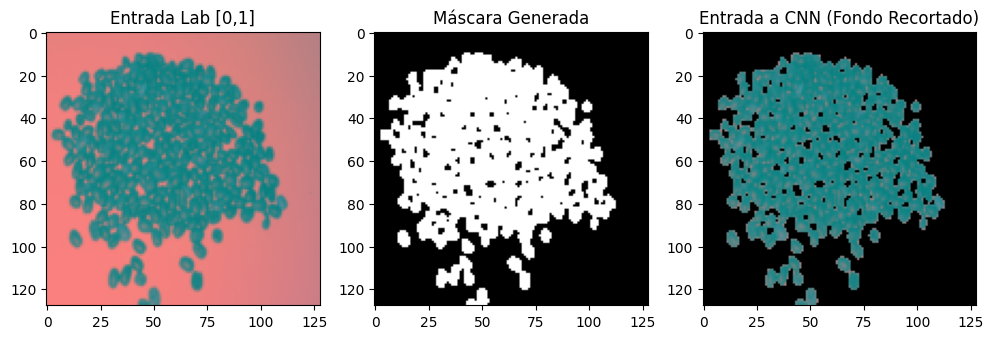


📊 Calculando métricas Modelo A...
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00        50
       Green       1.00      1.00      1.00        50
       Light       0.98      1.00      0.99        50
      Medium       1.00      0.98      0.99        50
  Overbaking       1.00      1.00      1.00        50

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

Exactitud (Accuracy): 0.9960
Kappa de Cohen:      0.9950


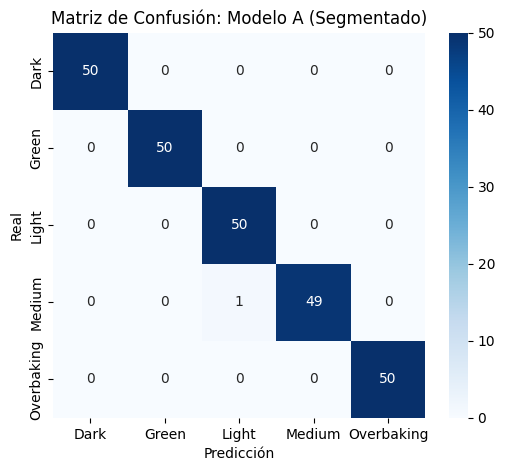

In [ ]:
# ==========================================
# 6. EVALUACIÓN MODELO A (PIPELINE SEGMENTADO)
# ==========================================
print("\n" + "="*50)
print("🚀 INICIANDO EVALUACIÓN MODELO A (SEGMENTADO)")
print("="*50)

# Dataset Crudo [0, 1] para Modelo A
class CoffeeRawDataset(Dataset):
    def __init__(self, df):
        self.paths = df['path'].tolist()
        self.labels = df['label'].tolist()
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            img_pil = Image.open(self.paths[idx]).convert('RGB').resize(IMG_SIZE, Image.BILINEAR)
            img_np = np.array(img_pil)
            # Convertir a Lab
            img_lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2Lab)
            # Escalar a [0, 1] pero NO normalizar estadísticamente aún
            img_float = img_lab.astype(np.float32) / 255.0
            tensor = torch.from_numpy(np.transpose(img_float, (2, 0, 1))).float()
            return tensor, self.labels[idx]
        except:
            return torch.zeros(3, 128, 128), self.labels[idx]

test_loader_A = DataLoader(CoffeeRawDataset(df_test), batch_size=BATCH_SIZE, shuffle=False)

# Función de normalización [-1, 1]
def normalize(t):
    return (t - 0.5) / 0.5

# 1. DEBUG VISUAL U-NET
def debug_unet_vis():
    print("\n🔍 Visualización de Segmentación U-Net (Una muestra):")
    imgs_raw, _ = next(iter(test_loader_A))
    imgs_raw = imgs_raw.to(DEVICE)

    # Pipeline de prueba
    unet_input = normalize(imgs_raw) # Normalizar para U-Net
    with torch.no_grad():
        logits = unet(unet_input)
        masks = (torch.sigmoid(logits) > 0.5).float()
        segmented_raw = imgs_raw * masks # Enmascarar en crudo
        cnn_input = normalize(segmented_raw) # Normalizar para CNN (Fondo 0 -> -1)

    # Mostrar
    idx = 0
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(np.clip(imgs_raw[idx].cpu().numpy().transpose(1, 2, 0), 0, 1))
    plt.title("Entrada Lab [0,1]")

    plt.subplot(1, 3, 2)
    plt.imshow(masks[idx].cpu().squeeze().numpy(), cmap='gray')
    plt.title("Máscara Generada")

    plt.subplot(1, 3, 3)
    # Des-normalizar la entrada de la CNN solo para ver que el fondo es negro
    cnn_vis = (cnn_input[idx].cpu().numpy().transpose(1, 2, 0) * 0.5) + 0.5
    plt.imshow(np.clip(cnn_vis, 0, 1))
    plt.title("Entrada a CNN (Fondo Recortado)")
    plt.show()

debug_unet_vis()

# 2. EVALUACIÓN MÉTRICAS MODELO A
print("\n📊 Calculando métricas Modelo A...")
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs_raw, lbls in test_loader_A:
        imgs_raw = imgs_raw.to(DEVICE)

        # Pipeline Correcto
        unet_input = normalize(imgs_raw)          # A. Normalizar para U-Net
        mask_logits = unet(unet_input)
        masks = (torch.sigmoid(mask_logits) > 0.5).float()

        segmented_raw = imgs_raw * masks          # B. Enmascarar (Fondo=0)

        cnn_input = normalize(segmented_raw)      # C. Normalizar (Fondo 0 -> -1)

        outputs = model_a(cnn_input)              # D. Clasificar
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))
acc = np.mean(np.array(all_labels) == np.array(all_preds))
kappa = cohen_kappa_score(all_labels, all_preds)
print(f"Exactitud (Accuracy): {acc:.4f}")
print(f"Kappa de Cohen:      {kappa:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Matriz de Confusión: Modelo A (Segmentado)")
plt.ylabel('Real'); plt.xlabel('Predicción')
plt.show()


🚀 INICIANDO EVALUACIÓN MODELO B (ORIGINAL)
📊 Calculando métricas Modelo B...
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00        50
       Green       1.00      1.00      1.00        50
       Light       0.98      0.98      0.98        50
      Medium       0.98      0.98      0.98        50
  Overbaking       1.00      1.00      1.00        50

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250

Exactitud (Accuracy): 0.9920
Kappa de Cohen:      0.9900


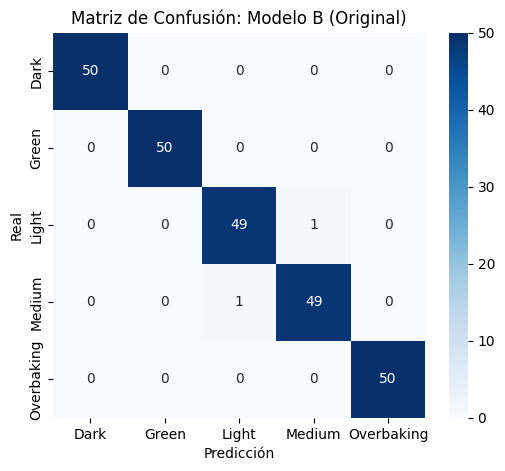

In [ ]:
# ==========================================
# 7. EVALUACIÓN MODELO B (ORIGINAL)
# ==========================================
print("\n" + "="*50)
print("🚀 INICIANDO EVALUACIÓN MODELO B (ORIGINAL)")
print("="*50)

class CoffeeOriginalDataset(Dataset):
    def __init__(self, df):
        self.paths = df['path'].tolist()
        self.labels = df['label'].tolist()
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            img_pil = Image.open(self.paths[idx]).convert('RGB').resize(IMG_SIZE, Image.BILINEAR)
            img_np = np.array(img_pil)
            img_lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2Lab)
            img_float = img_lab.astype(np.float32) / 255.0
            tensor = torch.from_numpy(np.transpose(img_float, (2, 0, 1))).float()
            # Normalización directa (Fondo blanco se mapea a valores altos)
            tensor = (tensor - 0.5) / 0.5
            return tensor, self.labels[idx]
        except:
            return torch.zeros(3, 128, 128), self.labels[idx]

test_loader_B = DataLoader(CoffeeOriginalDataset(df_test), batch_size=BATCH_SIZE, shuffle=False)

print("📊 Calculando métricas Modelo B...")
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in test_loader_B:
        imgs = imgs.to(DEVICE)
        outputs = model_b(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))
acc = np.mean(np.array(all_labels) == np.array(all_preds))
kappa = cohen_kappa_score(all_labels, all_preds)
print(f"Exactitud (Accuracy): {acc:.4f}")
print(f"Kappa de Cohen:      {kappa:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Matriz de Confusión: Modelo B (Original)")
plt.ylabel('Real'); plt.xlabel('Predicción')
plt.show()